In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [35]:
L = 20
chi = 1024
alpha = 0.0

In [36]:
filename = Path(f"results/n_profile_vs_t_L{L}_chi{chi}_alpha{alpha}.csv")

In [37]:
df = pd.read_csv(filename, comment="#")

In [38]:
required = ["time"] + [f'n_{j+1}' for j in range(L)]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in {filename}: {missing}")

In [39]:
times     = df['time'].values
n_matrix  = np.column_stack([df[f'n_{j+1}'].values for j in range(L)])
assert n_matrix.shape == (len(times), L), (
    f"n_matrix shape mismatch: {n_matrix.shape}"
)

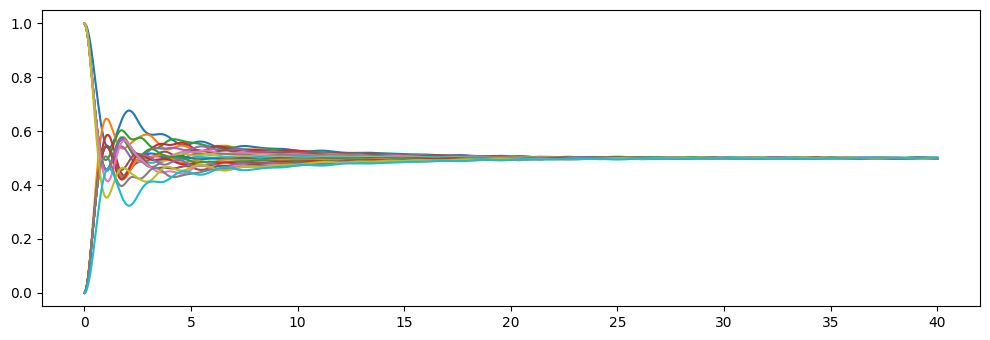

In [41]:
plt.figure(figsize=(10,3.5))
for j in range(L):
    plt.plot(times, n_matrix[:,j], label=f'n_{j}(t)')
plt.tight_layout()
plt.show()